# Telco Customer Churn — Data Science Mini Project
**Goal:** Find out *why* customers leave a telecom company and which factors predict churn.
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns) — the public version of the Kaggle dataset "Telco Customer Churn".
**Questions:**
1. What share of customers churn?
2. Which contract, service and billing factors drive churn?
3. Can a simple model flag at-risk customers?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
sns.set_theme(style="whitegrid", palette="Set2")

URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(URL)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Cleaning

In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')   # blank strings -> NaN
print("Missing TotalCharges:", df['TotalCharges'].isna().sum())
# those rows are brand-new customers (tenure = 0) -> no charges yet
print(df.loc[df['TotalCharges'].isna(), 'tenure'].unique())
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churned'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['customerID'])
df.describe().T

Missing TotalCharges: 11
[0]


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
Churned,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00


## 2. Exploratory analysis

Overall churn rate: 26.5%


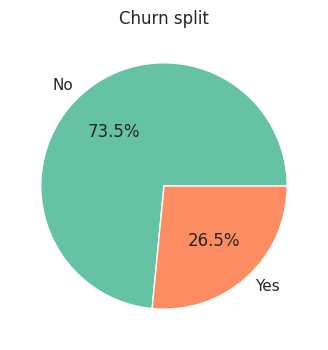

In [3]:
rate = df['Churned'].mean()
print(f"Overall churn rate: {rate:.1%}")
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(4,4), title='Churn split')
plt.ylabel(''); plt.show()

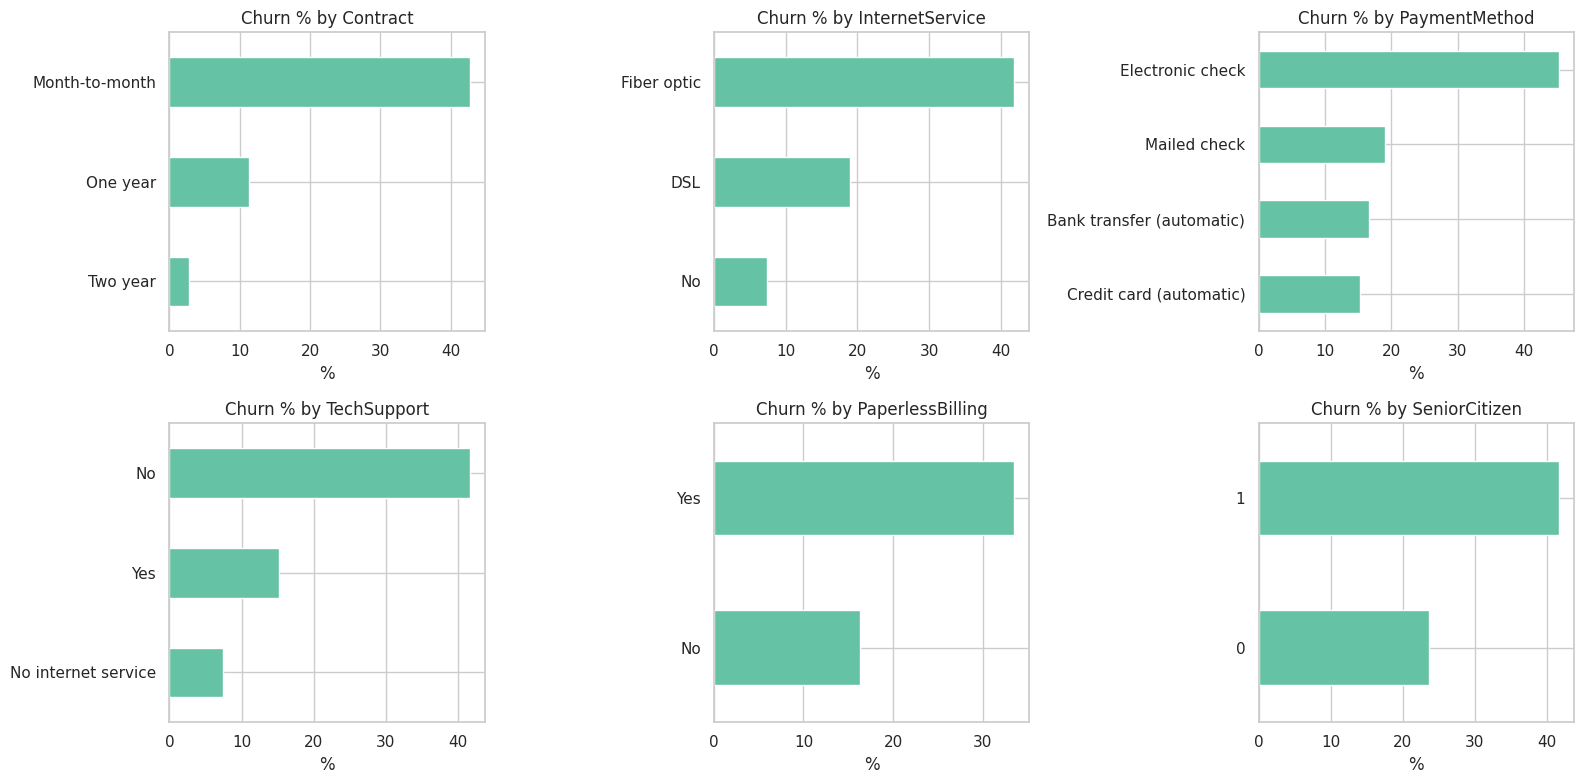

In [4]:
cols = ['Contract','InternetService','PaymentMethod','TechSupport','PaperlessBilling','SeniorCitizen']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cols):
    (df.groupby(c)['Churned'].mean()*100).sort_values().plot.barh(ax=ax)
    ax.set_title(f'Churn % by {c}'); ax.set_xlabel('%'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

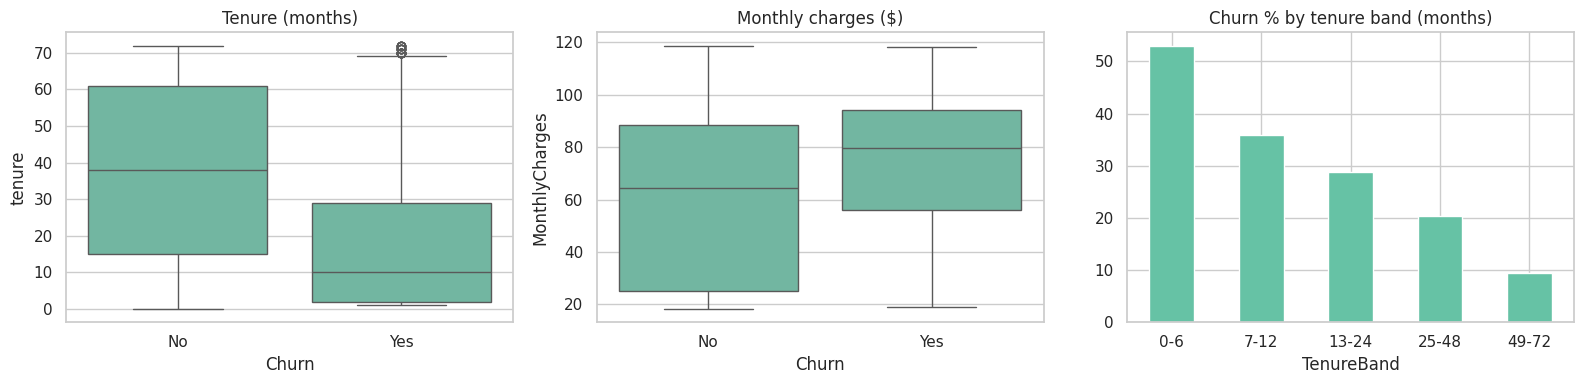

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0]);          axes[0].set_title('Tenure (months)')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1]);  axes[1].set_title('Monthly charges ($)')
df['TenureBand'] = pd.cut(df['tenure'], [-1,6,12,24,48,72], labels=['0-6','7-12','13-24','25-48','49-72'])
(df.groupby('TenureBand', observed=True)['Churned'].mean()*100).plot.bar(ax=axes[2], rot=0)
axes[2].set_title('Churn % by tenure band (months)')
plt.tight_layout(); plt.show()

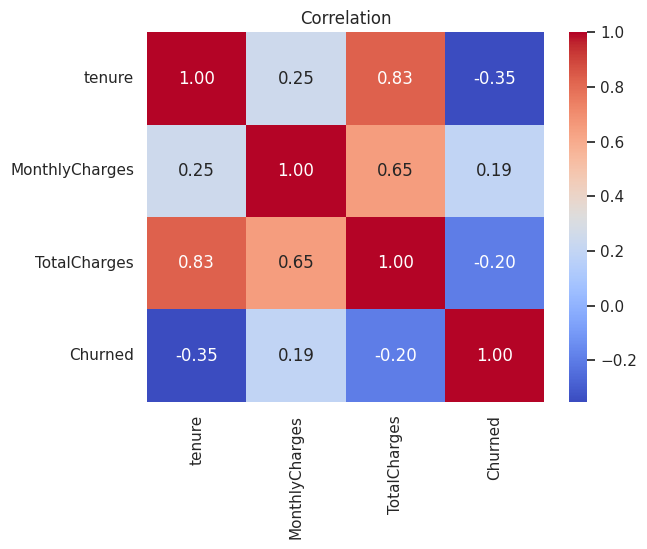

In [6]:
num = df[['tenure','MonthlyCharges','TotalCharges','Churned']]
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', fmt='.2f'); plt.title('Correlation'); plt.show()

## 3. Predictive model

In [7]:
X = pd.get_dummies(df.drop(columns=['Churn','Churned','TenureBand']), drop_first=True)
y = df['Churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', min_samples_leaf=5, random_state=42),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:,1]
    print(f"\n=== {name} | ROC-AUC = {roc_auc_score(y_test, proba):.3f} ===")
    print(classification_report(y_test, m.predict(X_test)))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression | ROC-AUC = 0.842 ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409




=== Random Forest | ROC-AUC = 0.843 ===
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



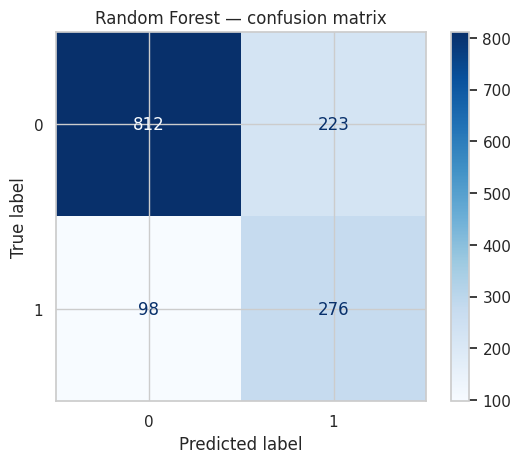

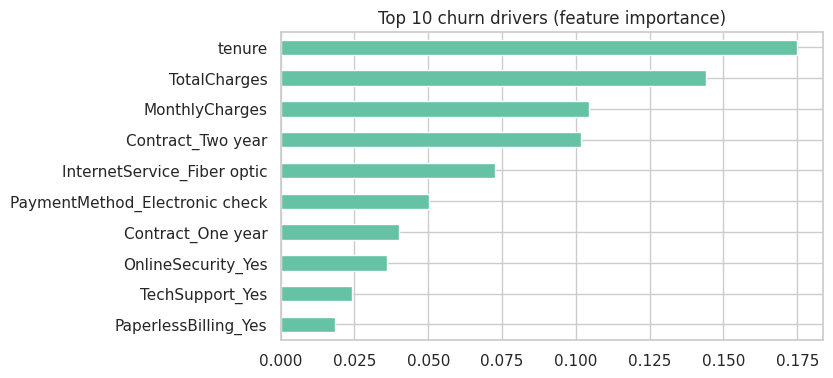

In [8]:
rf = models['Random Forest']
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues'); plt.title('Random Forest — confusion matrix'); plt.show()
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10)
imp.plot.barh(figsize=(7,4), title='Top 10 churn drivers (feature importance)'); plt.show()

## 4. Key findings
- **26.5%** of customers churned — roughly 1 in 4.
- **Contract type is the strongest signal:** month-to-month customers churn at **42.7%**, versus 11.3% (1-year) and 2.8% (2-year).
- **New customers leave first:** 52.9% of customers in their first 6 months churn, falling to 9.5% after 4 years.
- **Fiber optic customers churn at 41.9%**, over double DSL (19.0%) — and they pay the most. Likely a price/quality problem worth investigating.
- **Electronic check users churn at 45.3%** vs ~15–19% for other payment methods.
- **No tech support → 41.6% churn**, vs 15.2% with it.
- Churners pay more (median $79.65/month vs $64.43) and have much shorter tenure (median 10 vs 38 months).

## 5. Recommendations
1. Offer discounts to move month-to-month customers onto 1–2 year contracts.
2. Run an onboarding programme for the first 6 months.
3. Bundle tech support with fiber plans; investigate fiber service quality.
4. Nudge electronic-check users to automatic payments.

## 6. Limitations
Single snapshot dataset (no time dimension), correlation is not causation, and the model is a baseline — no hyperparameter tuning or cost-sensitive thresholding yet.